# GUÍA 3 – PARCIAL 1: TELEDETECCIÓN
## Opción 2: Dataset MASATI – Detección de Barcos
### Reto 3: «Comparación de los 2 conjuntos de datos»



---

Comparamos las **etiquetas originales** (dibujadas a mano por personas) con las **etiquetas refinadas por SAM** generadas en el Reto 2:

1. **Cuantitativamente:** *Intersection over Union* (IoU) entre cada par de cajas, con tablas por tipo de escena y por tamaño del barco.
2. **Visualmente:** imágenes aleatorias de cada tipo (un barco, costa con barcos, varios barcos, detalle) con ambas cajas en colores diferentes y acercamientos a cada barco.

$$IoU = \frac{|A \cap B|}{|A \cup B|}$$

Un IoU = 1 significa cajas idénticas y 0 que no se tocan. En detección de objetos, IoU ≥ 0,5 suele considerarse suficiente para decir que dos cajas señalan el mismo objeto (criterio de PASCAL VOC).

## 1. Configuración

In [12]:
import os, sys, random, zipfile
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display, Markdown

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ================== CONFIGURACIÓN ===========Z=================
# CARPETA_DRIVE = '/content/drive/MyDrive/Colab Vision/Guía 3'
CARPETA_DRIVE = '/content/drive/MyDrive/Vision'
RUTA_ZIP  = f'{CARPETA_DRIVE}/MASATI-v2.zip'
DATA_ROOT = '/content/MASATI-v2'                                   # aquí se descomprime el zip
RUTAS_SAM = [f'{CARPETA_DRIVE}/reto2_resultados/etiquetas_SAM']    # donde el Reto 2 guarda las *_labels_SAM
SALIDA    = Path(f'{CARPETA_DRIVE}/reto3_resultados')
# ==================================================================

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

if not Path(DATA_ROOT).exists() and Path(RUTA_ZIP).exists():
    print('Descomprimiendo', RUTA_ZIP, '->', DATA_ROOT)
    with zipfile.ZipFile(RUTA_ZIP) as z:
        z.extractall(DATA_ROOT)
assert Path(DATA_ROOT).exists(), f'No encuentro el dataset en {DATA_ROOT}'
SALIDA.mkdir(parents=True, exist_ok=True)

SCENES = {'ship': ('ship', 'ship_labels'), 'coast_ship': ('coast_ship', 'coast_ship_labels'),
          'multi': ('multi', 'multi_labels'), 'detail': ('detail', 'detail_labels')}

def buscar_carpeta(raiz, nombre):
    raiz = Path(raiz)
    if (raiz / nombre).is_dir(): return raiz / nombre
    return next((p for p in raiz.rglob(nombre) if p.is_dir()), None)

CARPETAS = {}
for escena, (img_dir, lbl_dir) in SCENES.items():
    d_img, d_lbl = buscar_carpeta(DATA_ROOT, img_dir), buscar_carpeta(DATA_ROOT, lbl_dir)
    d_sam = next((d for r in RUTAS_SAM if Path(r).exists() and (d := buscar_carpeta(r, lbl_dir + '_SAM'))), None)
    print(f'{escena:11s} imágenes: {d_img}\n{"":11s} original: {d_lbl}\n{"":11s} SAM     : {d_sam}')
    if d_img and d_lbl and d_sam: CARPETAS[escena] = (d_img, d_lbl, d_sam)
assert CARPETAS, 'No se encontró ninguna carpeta *_labels_SAM. Revisen RUTAS_SAM.'
print('\nEscenas a comparar:', list(CARPETAS))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ship        imágenes: /content/MASATI-v2/MASATI-v2/ship
            original: /content/MASATI-v2/MASATI-v2/ship_labels
            SAM     : /content/drive/MyDrive/Vision/reto2_resultados/etiquetas_SAM/ship_labels_SAM
coast_ship  imágenes: /content/MASATI-v2/MASATI-v2/coast_ship
            original: /content/MASATI-v2/MASATI-v2/coast_ship_labels
            SAM     : /content/drive/MyDrive/Vision/reto2_resultados/etiquetas_SAM/coast_ship_labels_SAM
multi       imágenes: /content/MASATI-v2/MASATI-v2/multi
            original: /content/MASATI-v2/MASATI-v2/multi_labels
            SAM     : /content/drive/MyDrive/Vision/reto2_resultados/etiquetas_SAM/multi_labels_SAM
detail      imágenes: /content/MASATI-v2/MASATI-v2/detail
            original: None
            SAM     : None

Escenas a comparar: ['ship', 'coast_ship', 'multi']


In [13]:
def parse_voc_xml(xml_path):
    # Devuelve el nombre de la imagen y {índice_del_objeto: (xmin, ymin, xmax, ymax)}.
    # Normaliza coordenadas invertidas y omite objetos sin <bndbox>.
    root = ET.parse(xml_path).getroot()
    cajas = {}
    for i, obj in enumerate(root.iter('object')):
        bb = obj.find('bndbox')
        if bb is None: continue
        x1, y1, x2, y2 = (int(round(float(bb.findtext(k)))) for k in ('xmin', 'ymin', 'xmax', 'ymax'))
        cajas[i] = (min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2))
    return (root.findtext('filename') or '').strip(), cajas

def buscar_imagen(d_img, filename, base):
    for nombre in [filename, base + '.png', base + '.jpg']:
        if nombre and (Path(d_img) / nombre).exists(): return Path(d_img) / nombre
    return next(iter(Path(d_img).glob(base + '.*')), None)

def leer_imagen(ruta):
    return np.array(Image.open(ruta).convert('RGB'))

COLOR_ORIG = '#00e676'   # verde: etiqueta original (humana)
COLOR_SAM  = '#ff1744'   # rojo : etiqueta SAM

def rect(ax, caja, color, lw=2, ls='-'):
    # Las coordenadas son píxeles inclusivos: el borde va desde x1-0.5 hasta x2+0.5
    x1, y1, x2, y2 = caja
    ax.add_patch(patches.Rectangle((x1 - .5, y1 - .5), x2 - x1 + 1, y2 - y1 + 1,
                                   fill=False, edgecolor=color, linewidth=lw, linestyle=ls))

def recorte(img, caja, margen=0.8, minimo=24):
    # Ventana cuadrada alrededor de la caja para hacer zoom; devuelve (sub-imagen, x0, y0)
    x1, y1, x2, y2 = caja
    lado = max(minimo, int(max(x2 - x1 + 1, y2 - y1 + 1) * (1 + 2 * margen)))
    H, W = img.shape[:2]
    x0 = int(np.clip((x1 + x2) / 2 - lado / 2, 0, max(0, W - lado)))
    y0 = int(np.clip((y1 + y2) / 2 - lado / 2, 0, max(0, H - lado)))
    return img[y0:y0 + lado, x0:x0 + lado], x0, y0

## 2. Emparejamiento de las cajas e IoU

Cada barco se empareja por su **posición dentro del XML** (`obj_idx`), que es la misma en el original y en la copia `_SAM`. Se empareja por índice y no por orden de lista: si a un XML `_SAM` le faltara un objeto o el archivo completo, ese barco se omite y se reporta, en lugar de detener todo el cálculo.

El IoU de todos los pares se calcula con **`torchvision.ops.box_iou`** (librería) y se verifica con una implementación manual. Las coordenadas del XML son píxeles **inclusivos**: una caja de `xmin = 10` a `xmax = 17` mide 8 px, no 7. Por eso se suma 1 a `xmax` y `ymax`; sin ese ajuste, el IoU de los barcos pequeños queda sesgado.

In [14]:
import torch
from torchvision.ops import box_iou

rows, faltan_xml, faltan_obj, faltan_img = [], 0, 0, 0
for escena, (d_img, d_lbl, d_sam) in CARPETAS.items():
    for xml_o in sorted(Path(d_lbl).glob('*.xml')):
        xml_s = Path(d_sam) / xml_o.name
        if not xml_s.exists(): faltan_xml += 1; continue
        fn, cajas_o = parse_voc_xml(xml_o)
        _, cajas_s = parse_voc_xml(xml_s)
        ruta_img = buscar_imagen(d_img, fn, xml_o.stem)
        if ruta_img is None: faltan_img += 1; continue
        for idx, o in cajas_o.items():
            if idx not in cajas_s: faltan_obj += 1; continue
            s = cajas_s[idx]
            rows.append({'scene': escena, 'file': xml_o.stem, 'imagen': str(ruta_img), 'obj_idx': idx,
                         'xmin': o[0], 'ymin': o[1], 'xmax': o[2], 'ymax': o[3],
                         'sam_xmin': s[0], 'sam_ymin': s[1], 'sam_xmax': s[2], 'sam_ymax': s[3]})
df = pd.DataFrame(rows)
O = ['xmin', 'ymin', 'xmax', 'ymax']; S = ['sam_xmin', 'sam_ymin', 'sam_xmax', 'sam_ymax']

def iou_box(a, b):
    # IoU manual entre dos cajas (xmin, ymin, xmax, ymax) con píxeles inclusivos
    iw = max(0, min(a[2], b[2]) - max(a[0], b[0]) + 1)
    ih = max(0, min(a[3], b[3]) - max(a[1], b[1]) + 1)
    inter = iw * ih
    area = lambda c: (c[2] - c[0] + 1) * (c[3] - c[1] + 1)
    return inter / (area(a) + area(b) - inter)

# IoU con torchvision, imagen por imagen (+1 a xmax/ymax por ser píxeles inclusivos)
df['iou'] = 0.0
for _, idx in df.groupby('imagen').indices.items():
    A = np.array(df.iloc[idx][O], dtype=np.float32); A[:, 2:] += 1
    B = np.array(df.iloc[idx][S], dtype=np.float32); B[:, 2:] += 1
    df.iloc[idx, df.columns.get_loc('iou')] = np.diag(box_iou(torch.as_tensor(A), torch.as_tensor(B)).numpy())

# Verificación contra la implementación manual en TODOS los pares
iou_manual = np.array([iou_box(a, b) for a, b in zip(df[O].values, df[S].values)])
assert np.allclose(df.iou, iou_manual, atol=1e-5), 'torchvision y la implementación manual no coinciden'

df['area_orig'] = (df.xmax - df.xmin + 1) * (df.ymax - df.ymin + 1)
df['area_sam']  = (df.sam_xmax - df.sam_xmin + 1) * (df.sam_ymax - df.sam_ymin + 1)
df['size_px']   = np.maximum(df.xmax - df.xmin + 1, df.ymax - df.ymin + 1)   # lado mayor de la caja original
df['sam_mas_pequena'] = df.area_sam < df.area_orig
df['sam_dentro'] = ((df.sam_xmin >= df.xmin) & (df.sam_ymin >= df.ymin) &
                    (df.sam_xmax <= df.xmax) & (df.sam_ymax <= df.ymax))
df['size_bin'] = pd.cut(df.size_px, bins=[0, 15, 25, 40, 80, 10_000],
                        labels=['<15 px', '15–25', '25–40', '40–80', '>80'])
ESCENAS = [e for e in SCENES if e in set(df.scene)]
df.to_csv(SALIDA / 'iou_por_barco.csv', index=False)

print(f'Pares evaluados: {len(df):,}')
print(f'Omitidos -> XML _SAM faltantes: {faltan_xml} · objetos sin pareja: {faltan_obj} · imágenes no encontradas: {faltan_img}')
print('IoU de torchvision verificado contra la implementación manual en todos los pares ✔')

Pares evaluados: 4,054
Omitidos -> XML _SAM faltantes: 0 · objetos sin pareja: 0 · imágenes no encontradas: 0
IoU de torchvision verificado contra la implementación manual en todos los pares ✔


### 3. Comparación visual: cajas originales vs. SAM

- **Verde:** etiqueta original (humana)
- **Rojo discontinuo:** etiqueta refinada por SAM

Cada fila es una imagen aleatoria: a la izquierda la imagen completa y a la derecha el acercamiento a sus dos primeros barcos con el IoU de cada uno. Los acercamientos son necesarios porque la mayoría de los barcos mide menos de 20 px en una imagen de 512 px; sin ellos las dos cajas se ven una encima de otra. Cambien la `seed` para ver otras imágenes.

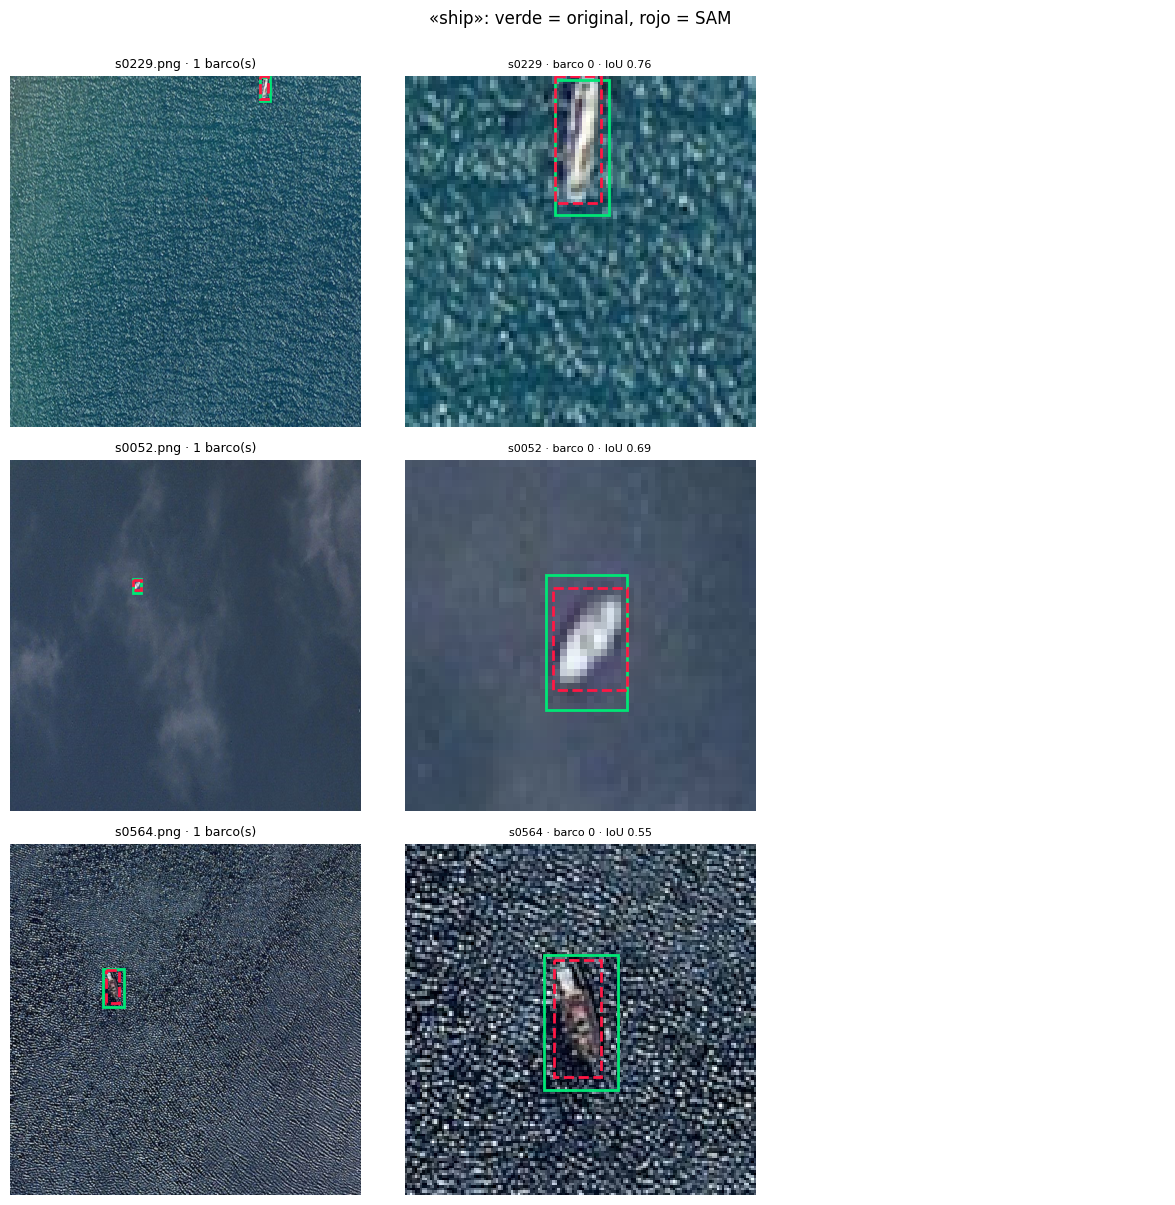

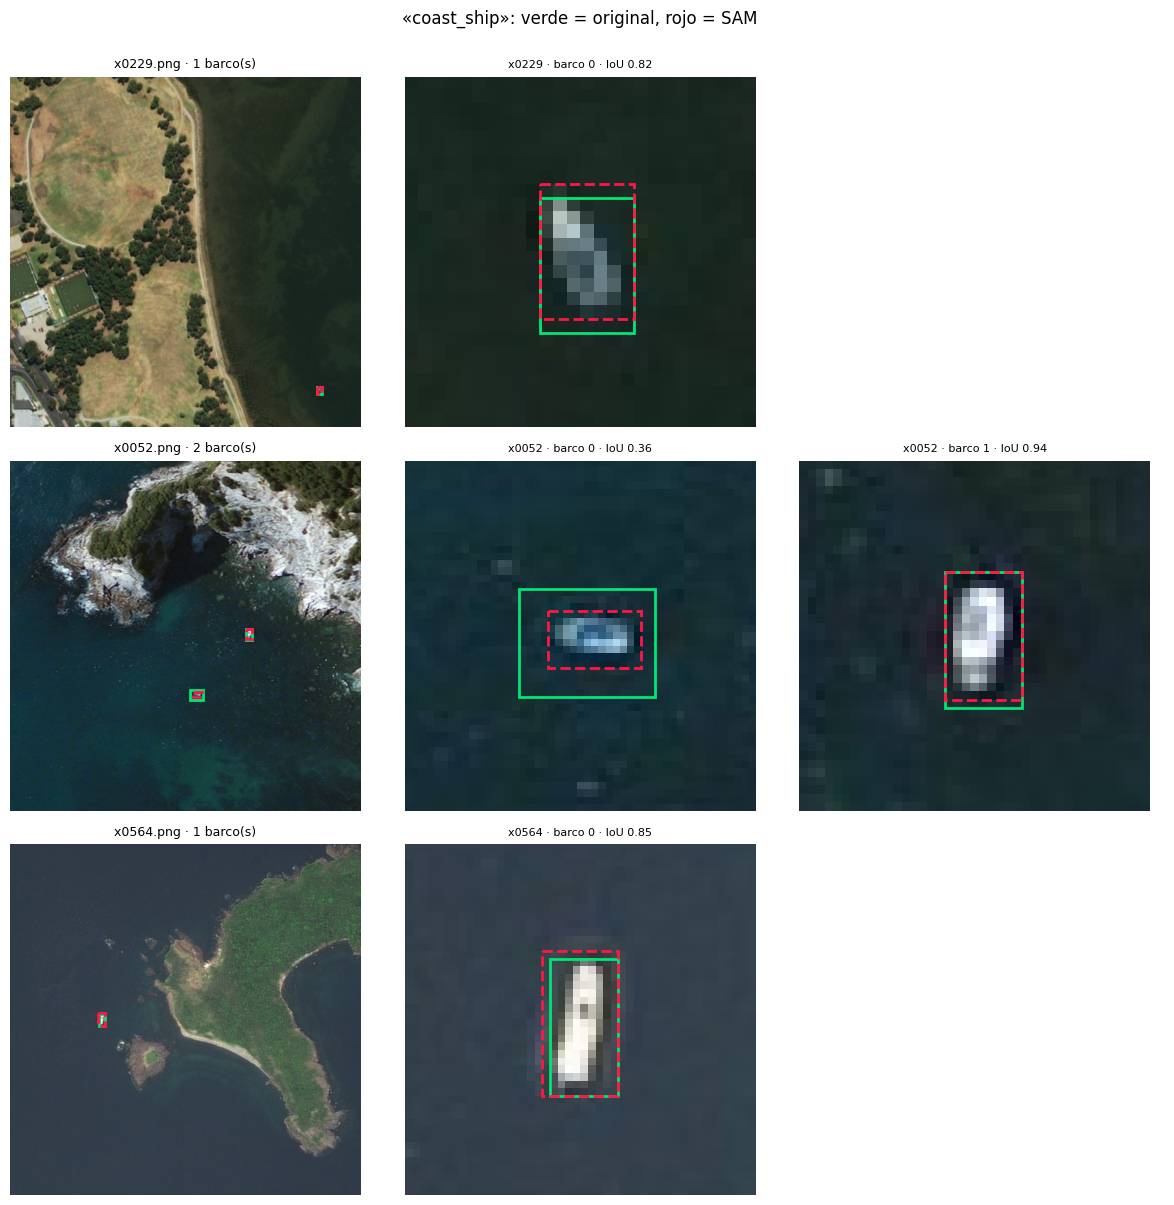

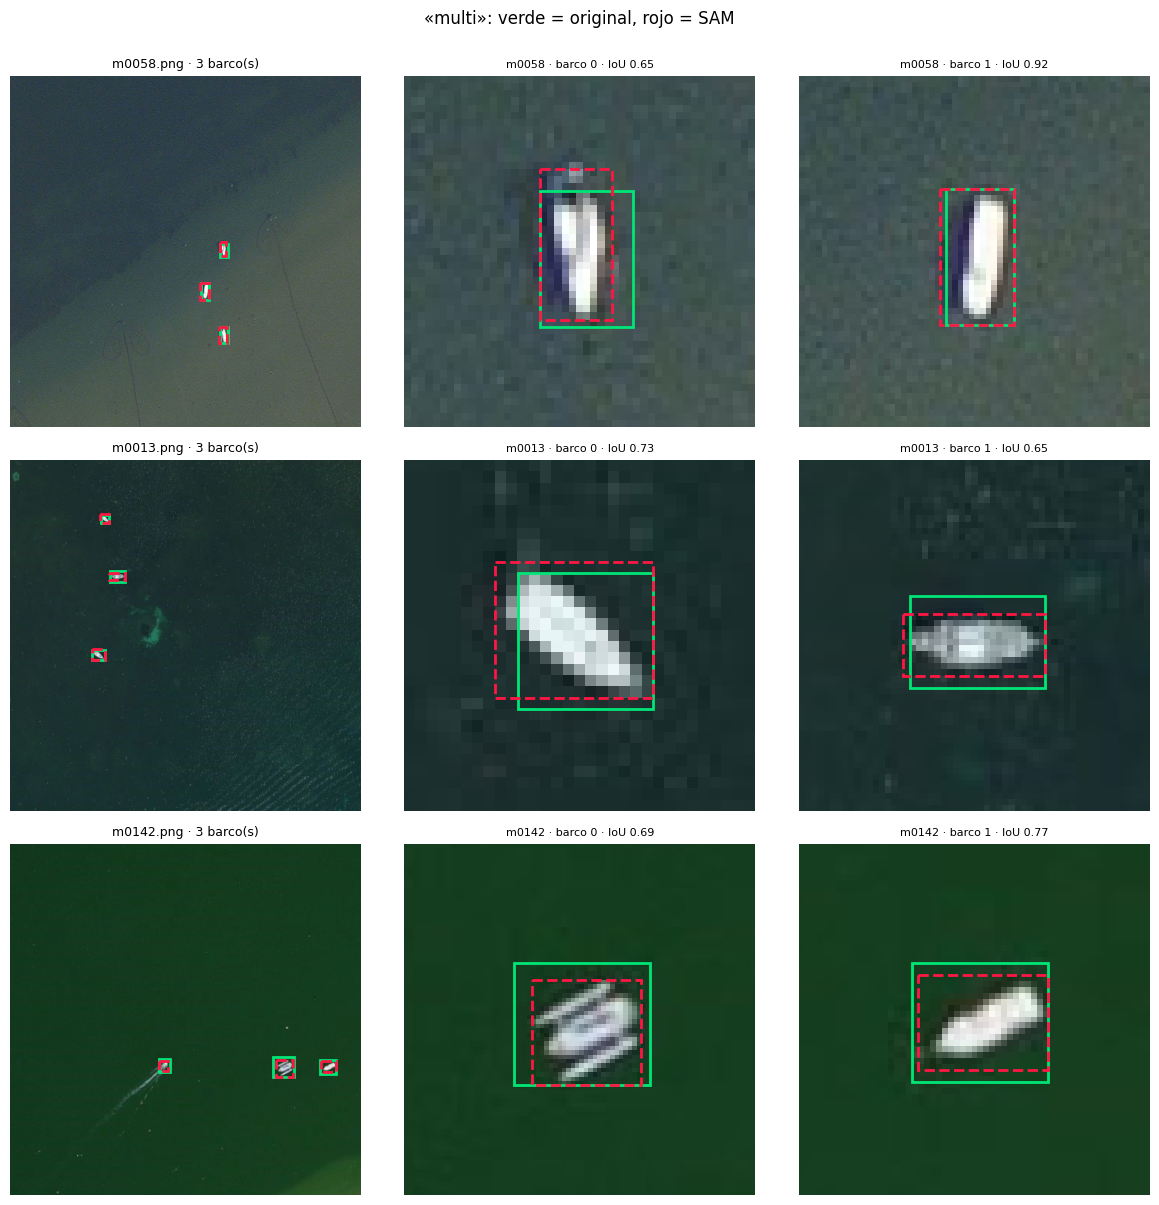

In [15]:
def zoom(ax, img, r):
    c, x0, y0 = recorte(img, (r.xmin, r.ymin, r.xmax, r.ymax))
    ax.imshow(c, interpolation='nearest')
    rect(ax, (r.xmin - x0, r.ymin - y0, r.xmax - x0, r.ymax - y0), COLOR_ORIG)
    rect(ax, (r.sam_xmin - x0, r.sam_ymin - y0, r.sam_xmax - x0, r.sam_ymax - y0), COLOR_SAM, ls='--')
    ax.set_title(f'{r.file} · barco {r.obj_idx} · IoU {r.iou:.2f}', fontsize=8)
    ax.axis('off')

def show_comparison(scene, n=3, seed=SEED):
    rutas = sorted(df.loc[df.scene == scene, 'imagen'].unique())
    sel = random.Random(seed).sample(rutas, min(n, len(rutas)))
    fig, axs = plt.subplots(len(sel), 3, figsize=(12, 4 * len(sel)), squeeze=False)
    for fila, ruta in zip(axs, sel):
        img = leer_imagen(ruta); g = df[df.imagen == ruta]
        fila[0].imshow(img)
        for _, r in g.iterrows():
            rect(fila[0], (r.xmin, r.ymin, r.xmax, r.ymax), COLOR_ORIG)
            rect(fila[0], (r.sam_xmin, r.sam_ymin, r.sam_xmax, r.sam_ymax), COLOR_SAM, ls='--')
        fila[0].set_title(f'{Path(ruta).name} · {len(g)} barco(s)', fontsize=9); fila[0].axis('off')
        for k, ax in enumerate(fila[1:]):
            if k < len(g): zoom(ax, img, g.iloc[k])
            else: ax.axis('off')
    plt.suptitle(f'«{scene}»: verde = original, rojo = SAM', y=1.0)
    plt.tight_layout(); plt.savefig(SALIDA / f'comparacion_{scene}.png', dpi=120, bbox_inches='tight'); plt.show()

for scene in ESCENAS:
    show_comparison(scene, n=3)

## 3. Tablas de resultados (evidencia cuantitativa)

Además de las estadísticas del IoU, la tabla indica en qué porcentaje de los pares la caja SAM es **más pequeña** que la original y en cuántos queda **completamente dentro** de ella. Esas dos columnas permiten afirmar con números si la anotación humana es holgada.

In [16]:
def resumen(g):
    s = g.iou
    return pd.Series({'n': len(g), 'media': s.mean(), 'mediana': s.median(), 'std': s.std(),
                      'min': s.min(), 'p25': s.quantile(.25), 'p75': s.quantile(.75), 'max': s.max(),
                      '% IoU≥0.5': 100 * (s >= .5).mean(), '% IoU≥0.75': 100 * (s >= .75).mean(),
                      '% SAM más pequeña': 100 * g.sam_mas_pequena.mean(),
                      '% SAM dentro de la original': 100 * g.sam_dentro.mean()})

summary = df.groupby('scene').apply(resumen).reindex(ESCENAS)
summary.loc['TODAS'] = resumen(df)
print('=== IoU original vs SAM, por escena ===')
display(summary.round(3))

tab = df.groupby('size_bin', observed=True).apply(resumen)[['n', 'media', 'mediana', 'p25', 'p75', '% IoU≥0.5']]
print('=== IoU según tamaño del barco (lado mayor de la caja original) ===')
display(tab.round(3))

summary.round(4).to_csv(SALIDA / 'iou_resumen_escena.csv')
tab.round(4).to_csv(SALIDA / 'iou_por_tamano.csv')

=== IoU original vs SAM, por escena ===


/tmp/ipykernel_971/1226108963.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby('scene').apply(resumen).reindex(ESCENAS)


,n,media,mediana,std,min,p25,p75,max,% IoU≥0.5,% IoU≥0.75,% SAM más pequeña,% SAM dentro de la original
scene,,,,,,,,,,,,
ship,1027.0,0.655,0.659,0.116,0.206,0.580,0.733,1.0,90.847,21.422,94.742,68.354
coast_ship,1061.0,0.754,0.780,0.155,0.214,0.652,0.860,1.0,93.308,58.718,41.753,38.360
multi,1966.0,0.638,0.644,0.145,0.200,0.536,0.745,1.0,81.841,24.619,89.522,58.901
TODAS,4054.0,0.672,0.679,0.149,0.200,0.569,0.781,1.0,87.124,32.733,78.342,55.920


=== IoU según tamaño del barco (lado mayor de la caja original) ===


/tmp/ipykernel_971/1226108963.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tab = df.groupby('size_bin', observed=True).apply(resumen)[['n', 'media', 'mediana', 'p25', 'p75', '% IoU≥0.5']]


,n,media,mediana,p25,p75,% IoU≥0.5
size_bin,,,,,,
<15 px,1859.0,0.666,0.667,0.545,0.795,83.163
15–25,1300.0,0.672,0.676,0.571,0.778,87.846
25–40,651.0,0.685,0.688,0.595,0.777,93.395
40–80,222.0,0.684,0.704,0.617,0.750,96.847
>80,22.0,0.722,0.727,0.683,0.769,95.455


## 4. Gráficas y casos extremos

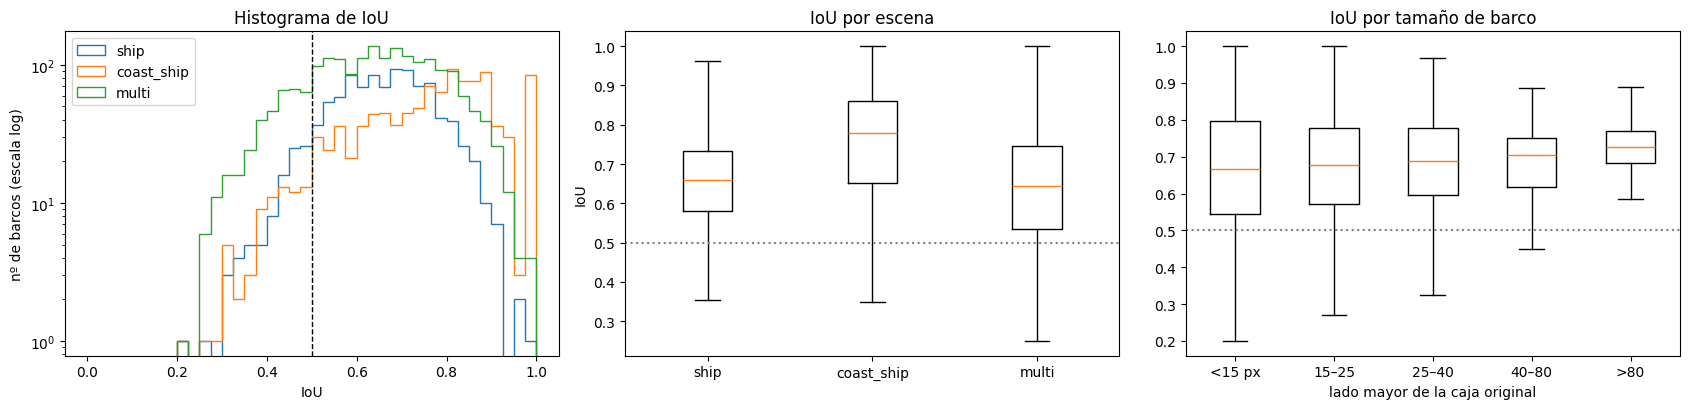

=== 5 MEJORES pares ===


,scene,file,obj_idx,iou,size_px
1016,ship,s1017,0,1.0,4
1164,coast_ship,x0124,0,1.0,5
1166,coast_ship,x0126,0,1.0,8
1175,coast_ship,x0135,0,1.0,18
1180,coast_ship,x0140,0,1.0,5


=== 5 PEORES pares (candidatos a inspección) ===


,scene,file,obj_idx,iou,size_px
3535,multi,y0010,6,0.200,10
876,ship,s0877,0,0.206,20
1392,coast_ship,x0352,0,0.214,3
3540,multi,y0010,11,0.250,10
3570,multi,y0011,29,0.255,15


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for scene in ESCENAS:
    axes[0].hist(df.loc[df.scene == scene, 'iou'], bins=np.linspace(0, 1, 41), histtype='step', lw=2, label=scene)
axes[0].axvline(0.5, color='k', ls='--', lw=1); axes[0].set_yscale('log')
axes[0].set_xlabel('IoU'); axes[0].set_ylabel('nº de barcos (escala log)'); axes[0].set_title('Histograma de IoU'); axes[0].legend()

axes[1].boxplot([df.loc[df.scene == e, 'iou'] for e in ESCENAS], showfliers=False)
axes[1].set_xticks(range(1, len(ESCENAS) + 1)); axes[1].set_xticklabels(ESCENAS)
axes[1].axhline(0.5, color='gray', ls=':'); axes[1].set_ylabel('IoU'); axes[1].set_title('IoU por escena')

bins = [b for b in df.size_bin.cat.categories if (df.size_bin == b).any()]
axes[2].boxplot([df.loc[df.size_bin == b, 'iou'] for b in bins], showfliers=False)
axes[2].set_xticks(range(1, len(bins) + 1)); axes[2].set_xticklabels(bins)
axes[2].axhline(0.5, color='gray', ls=':'); axes[2].set_xlabel('lado mayor de la caja original')
axes[2].set_title('IoU por tamaño de barco')
plt.tight_layout(); plt.savefig(SALIDA / 'graficas_iou.png', dpi=120, bbox_inches='tight'); plt.show()

cols = ['scene', 'file', 'obj_idx', 'iou', 'size_px']
print('=== 5 MEJORES pares ===');                          display(df.nlargest(5, 'iou')[cols].round(3))
print('=== 5 PEORES pares (candidatos a inspección) ===');  display(df.nsmallest(5, 'iou')[cols].round(3))

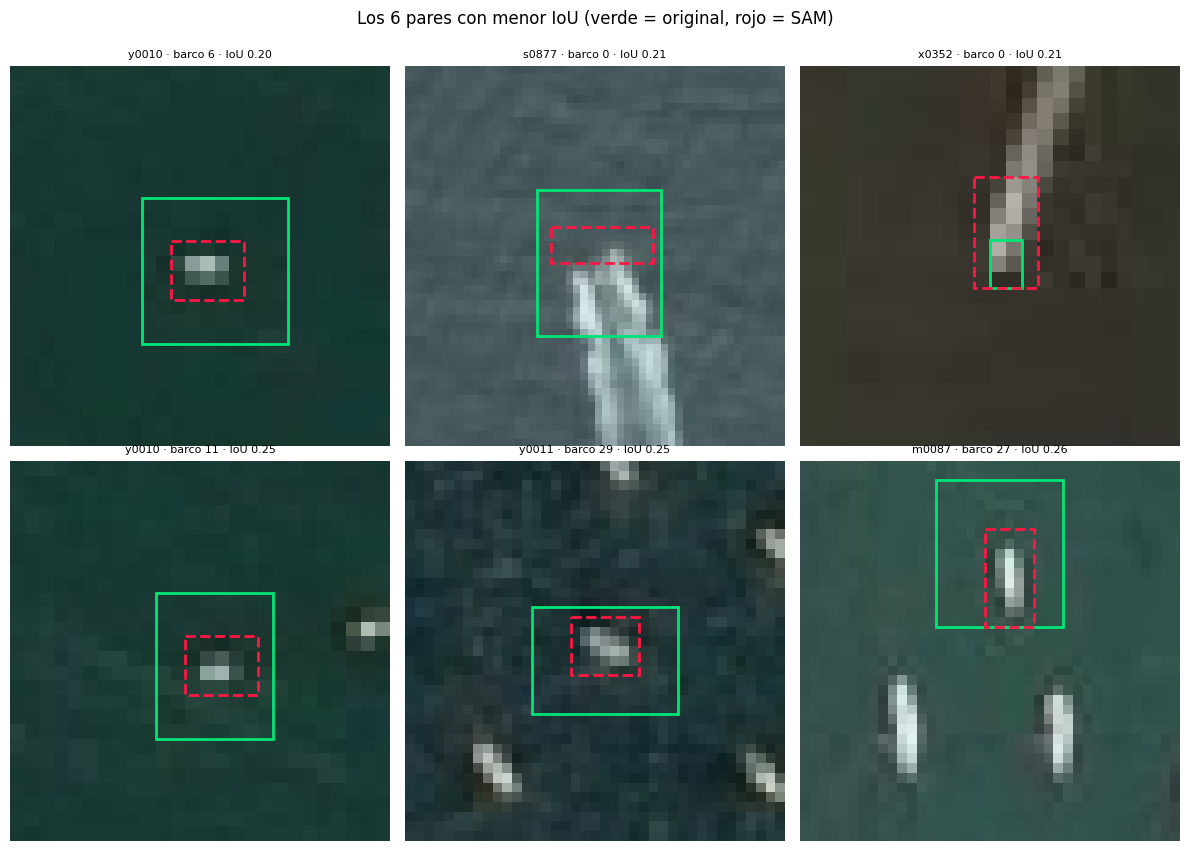

In [18]:
# Inspección visual de los 6 peores: acercamiento al barco concreto, con SU propio IoU
peores = df.nsmallest(6, 'iou')
fig, axs = plt.subplots(2, 3, figsize=(12, 8.5))
for ax, (_, r) in zip(axs.ravel(), peores.iterrows()):
    zoom(ax, leer_imagen(r.imagen), r)
for ax in axs.ravel()[len(peores):]: ax.axis('off')
plt.suptitle('Los 6 pares con menor IoU (verde = original, rojo = SAM)', y=1.0)
plt.tight_layout(); plt.savefig(SALIDA / 'peores_iou.png', dpi=120, bbox_inches='tight'); plt.show()

## 5. Conclusiones (cualitativas + cuantitativas)

**Cuantitativas**:

In [19]:
T = summary; tot = T.loc['TODAS']
mejor = T.drop('TODAS')['mediana'].idxmax(); peor = T.drop('TODAS')['mediana'].idxmin()
tt = tab['mediana']
if tot['% SAM dentro de la original'] >= 50:
    holgura = (f'En el **{tot["% SAM dentro de la original"]:.1f} %** de los pares la caja SAM queda completamente '
               f'**dentro** de la original y en el {tot["% SAM más pequeña"]:.1f} % es más pequeña: la anotación '
               f'humana tiende a ser **holgada**, con un margen de agua alrededor del barco.')
else:
    holgura = (f'Solo en el {tot["% SAM dentro de la original"]:.1f} % de los pares la caja SAM queda completamente '
               f'dentro de la original (es más pequeña en el {tot["% SAM más pequeña"]:.1f} %): las diferencias van en '
               f'ambas direcciones, así que no hay una tendencia clara de la anotación humana a ser holgada.')
texto = f'''
1. Se compararon **{int(tot["n"]):,} pares** de cajas. El IoU global tiene **media {tot["media"]:.3f}** y **mediana {tot["mediana"]:.3f}** (p25 = {tot["p25"]:.3f}, p75 = {tot["p75"]:.3f}). El **{tot["% IoU≥0.5"]:.1f} %** de los pares supera 0,5 y el {tot["% IoU≥0.75"]:.1f} % supera 0,75: las dos etiquetas casi siempre señalan el mismo barco, pero con distinto grado de ajuste.
2. {holgura}
3. Por escena, la mayor coincidencia está en `{mejor}` (mediana {T.loc[mejor, "mediana"]:.3f}) y la menor en `{peor}` (mediana {T.loc[peor, "mediana"]:.3f}).
4. Por tamaño, la mediana del IoU pasa de **{tt.iloc[0]:.3f}** en barcos «{tt.index[0]}» a **{tt.iloc[-1]:.3f}** en barcos «{tt.index[-1]}». En un barco pequeño, 1 o 2 píxeles de diferencia por lado son una fracción grande de la caja, así que el IoU castiga mucho más a los barcos pequeños.
'''
display(Markdown(texto))


1. Se compararon **4,054 pares** de cajas. El IoU global tiene **media 0.672** y **mediana 0.679** (p25 = 0.569, p75 = 0.781). El **87.1 %** de los pares supera 0,5 y el 32.7 % supera 0,75: las dos etiquetas casi siempre señalan el mismo barco, pero con distinto grado de ajuste.
2. En el **55.9 %** de los pares la caja SAM queda completamente **dentro** de la original y en el 78.3 % es más pequeña: la anotación humana tiende a ser **holgada**, con un margen de agua alrededor del barco.
3. Por escena, la mayor coincidencia está en `coast_ship` (mediana 0.780) y la menor en `multi` (mediana 0.644).
4. Por tamaño, la mediana del IoU pasa de **0.667** en barcos «<15 px» a **0.727** en barcos «>80». En un barco pequeño, 1 o 2 píxeles de diferencia por lado son una fracción grande de la caja, así que el IoU castiga mucho más a los barcos pequeños.


**Cualitativas**:

1. **Etiquetado humano.** Las cajas originales se dibujaron a mano con el mouse, así que es esperable una imprecisión de algunos píxeles y una tendencia a dibujar la caja más grande, porque es más seguro incluir agua que cortar el barco. SAM ajusta la caja al borde de la máscara de forma **consistente, automática y repetible**.
2. **SAM no siempre acierta.** En los peores casos revisen cuál de estas causas aparece: barcos **muy pequeños** o de bajo contraste (SAM segmenta solo una parte), **estelas** (la espuma blanca pegada al casco puede quedar dentro o fuera de la máscara), barcos **junto a la costa o un muelle** (la máscara se extiende hacia tierra) y barcos **muy cercanos entre sí**. En esos casos la caja humana puede ser la correcta.
3. **Qué etiqueta usar.** Un IoU alto indica que las dos cajas coinciden, no cuál es la verdadera.
4. **Limitación común.** Ambas cajas son paralelas a los ejes; con barcos en diagonal las dos incluyen mucha agua. La máscara de SAM permitiría obtener cajas rotadas.
5. **Dataset final.** Queda un nuevo dataset con etiquetas `*_SAM` que puede usarse en el proyecto final del parcial 2.

### Referencias

- Kirillov, A., et al. (2023). Segment Anything. *ICCV 2023*. https://github.com/facebookresearch/segment-anything
- Everingham, M., et al. (2010). The PASCAL Visual Object Classes (VOC) Challenge. *IJCV, 88*(2).
- MASATI dataset v2, Universidad de Alicante: https://www.iuii.ua.es/datasets/masati/